In [3]:
import geopandas as gpd
import pandas as pd
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ee
import xarray as xr
import xee
from shapely.geometry import mapping
import json
ee.Authenticate()
ee.Initialize( opt_url='https://earthengine-highvolume.googleapis.com')

Reading Raster Data 
- get thhe bounding box of area of interest
-  we are using XEE for loading Data from GEE
-  Sentinel data,' Harmonized Sentinel-2 MSI: MultiSpectral Instrument, Level-2A (SR)':  https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED
-  Landsat 8 ,'USGS Landsat 8 Level 2, Collection 2':https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2
- the same can be done by downlaoding data and reading in Xarray
- Not ideal for bigger area DASK should be used for a larger area



In [4]:
# Define Bounding Box 
bbox1=[76.48815950000001, 9.165505398999999, 76.5081595, 9.185505399]


In [5]:
# converting to gee readable geometry
bbox = ee.Geometry.Rectangle(bbox1)

In [6]:
ee.Initialize()

# ---- AOI / time range ----
time_start = ee.Date('2024-01-01')
time_end   = ee.Date('2024-12-31')

# =========================================================
# Sentinel-2 (Surface Reflectance, Harmonized) — <20% cloud, mean composite
# =========================================================
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterDate(time_start, time_end)
          .filterBounds(bbox)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
          .select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']))
# Median Composite yearly
s2_median = s2_col.median().clip(bbox)

ds_s2 = xr.open_dataset(
    ee.ImageCollection([s2_median]),
    engine='ee',
    crs='EPSG:4326',
    scale=0.0001,
    geometry=bbox
)
ds_s2 = ds_s2.transpose('time', 'lat', 'lon')
# single composite image, no 'time' dim needed but included if xee keeps it



D:\Gokul_R_Kamath\Python\env\Lib\site-packages\xee\ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


# Sentinel 2

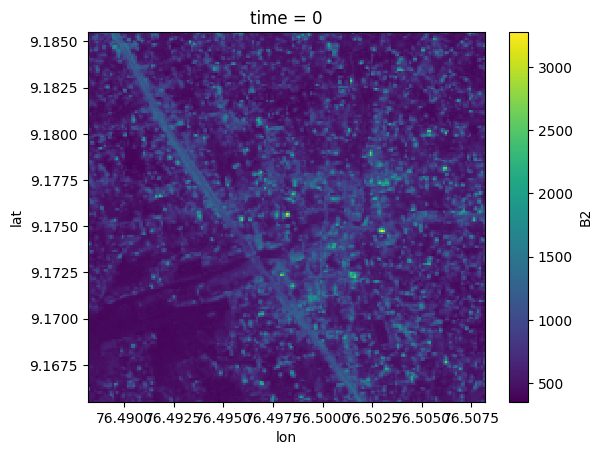

In [7]:
ds_s2['B2'][0].plot()

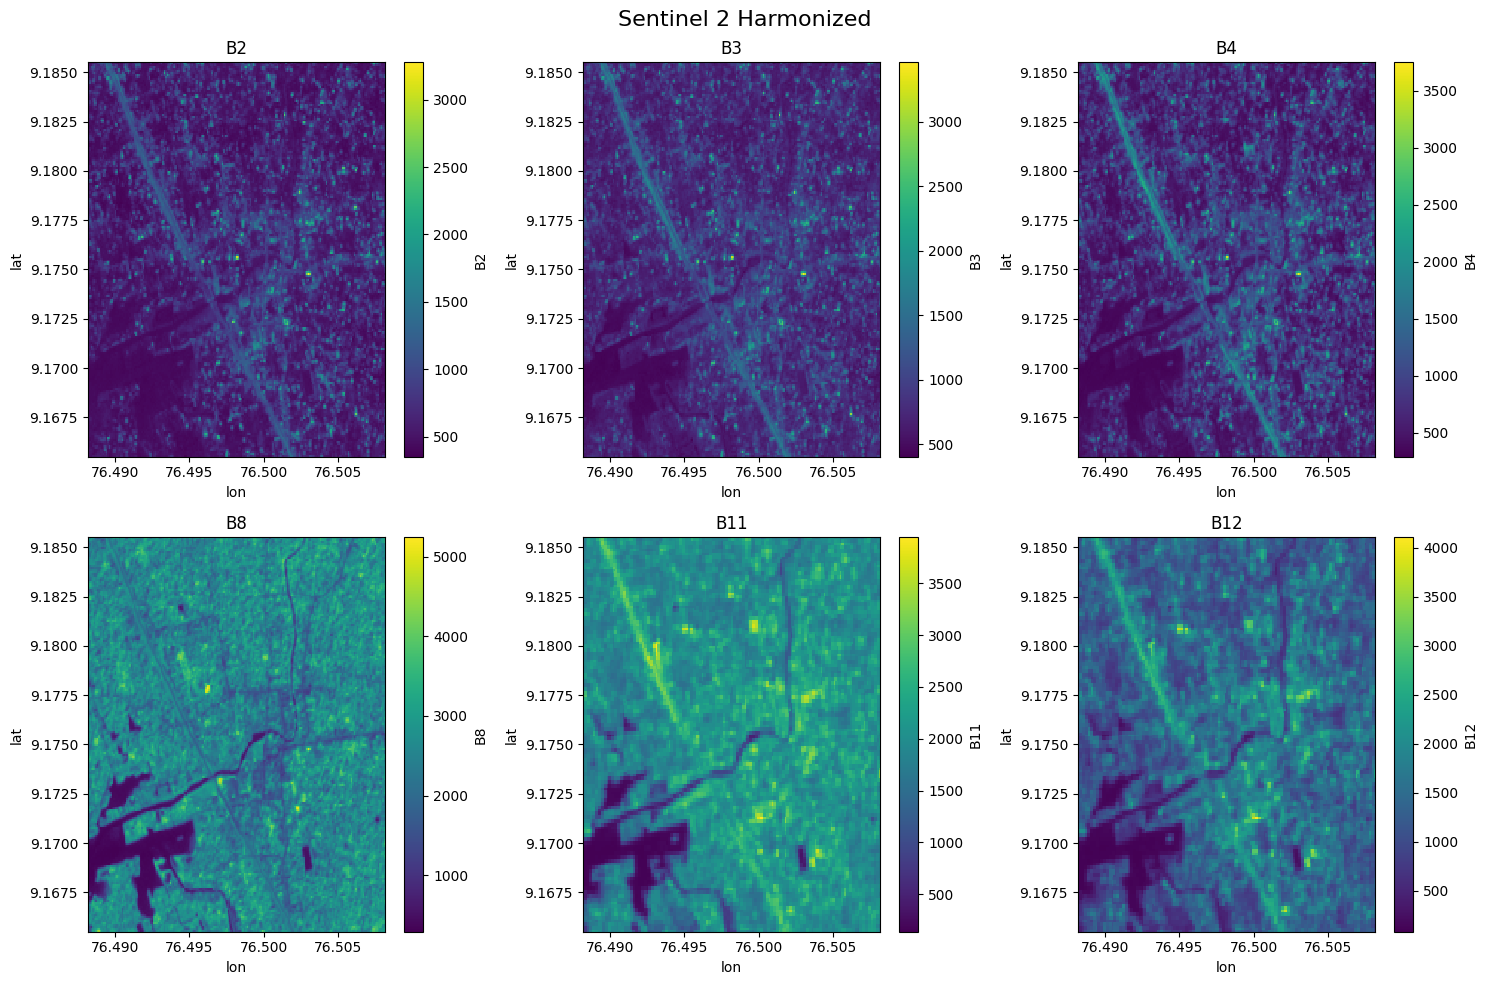

In [8]:
bands = list(ds_s2.data_vars)  # e.g. ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
n = len(bands)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # adjust rows/cols to match n
axes = axes.flatten()
for i, band in enumerate(bands):
    ds_s2[band][0].plot(ax=axes[i], cmap='viridis')
    axes[i].set_title(band)
fig.suptitle("Sentinel 2 Harmonized", fontsize=16)
plt.tight_layout()
plt.show()

## TCC

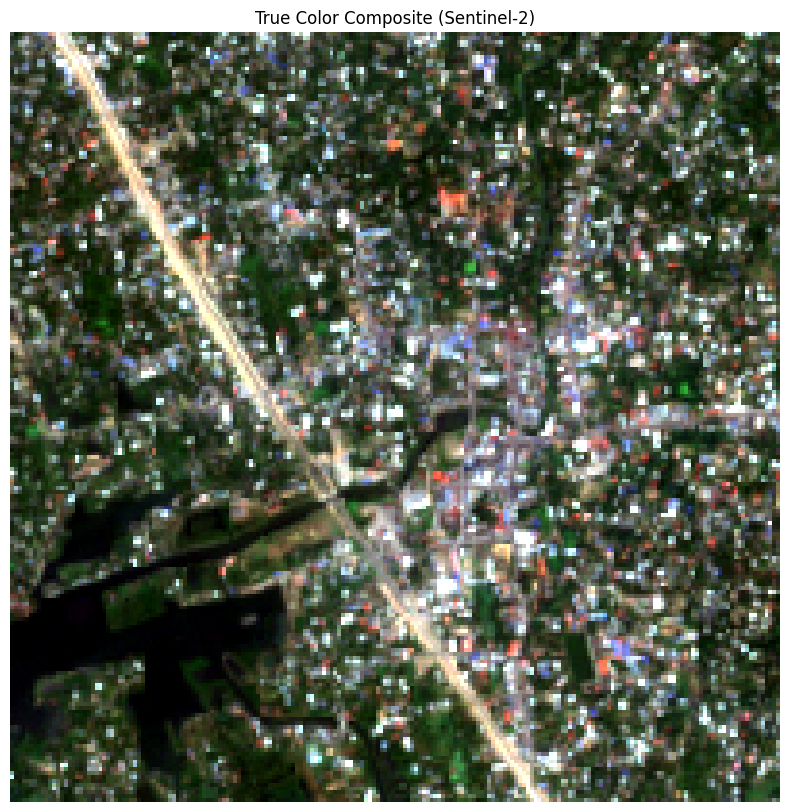

In [9]:
def normalize(band, low=2, high=98):
    vmin, vmax = np.nanpercentile(band, [low, high])
    return np.clip((band - vmin) / (vmax - vmin), 0, 1)

# Flip vertically if lat is ascending
red   = normalize(ds_s2['B4'][0].values)[::-1]
green = normalize(ds_s2['B3'][0].values)[::-1]
blue  = normalize(ds_s2['B2'][0].values)[::-1]

true_color = np.dstack([red, green, blue])

plt.figure(figsize=(10, 10))
plt.imshow(true_color)
plt.title('True Color Composite (Sentinel-2)')
plt.axis('off')
plt.show()

## FCC

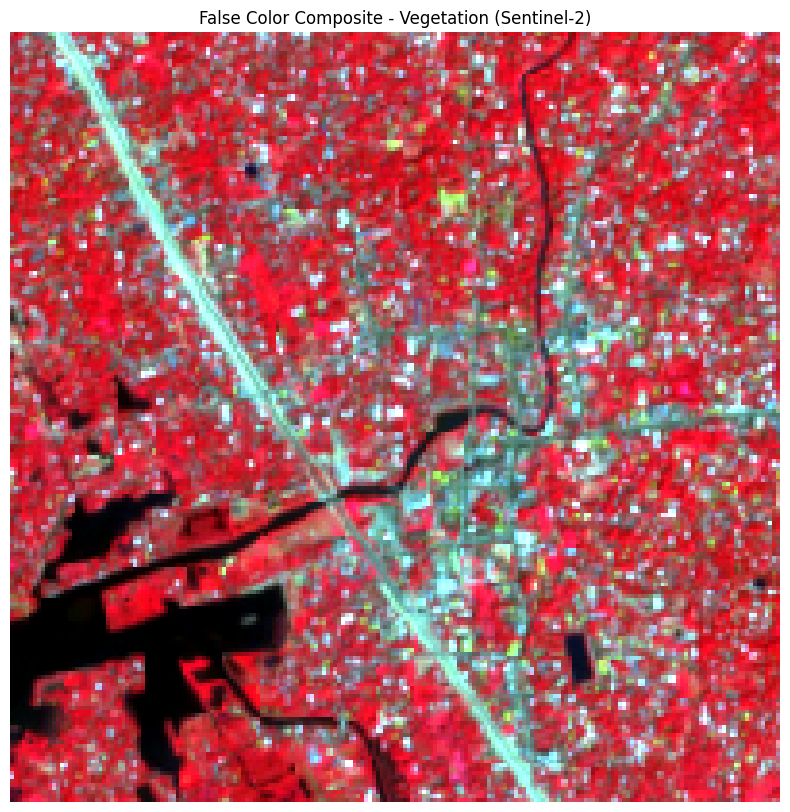

In [10]:
# =========================================================
# False Color Composite (R=B8/NIR, G=B4/Red, B=B3/Green)
# =========================================================
nir = normalize(ds_s2['B8'][0].values)[::-1]
red_fc = normalize(ds_s2['B4'][0].values)[::-1]
green_fc = normalize(ds_s2['B3'][0].values)[::-1]

false_color = np.dstack([nir, red_fc, green_fc])

plt.figure(figsize=(10, 10))
plt.imshow(false_color)
plt.title('False Color Composite - Vegetation (Sentinel-2)')
plt.axis('off')
plt.show()

## NDVI

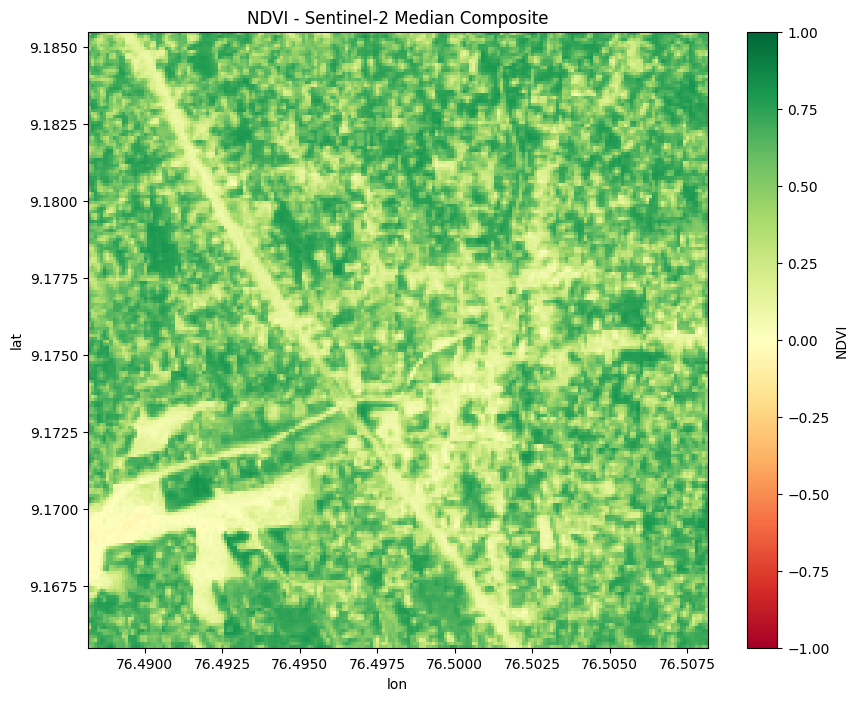

In [11]:
nir_raw = ds_s2['B8']
red_raw = ds_s2['B4']

ndvi = (nir_raw - red_raw) / (nir_raw + red_raw)
ndvi = ndvi.rename('NDVI')

plt.figure(figsize=(10, 8))
ndvi.plot(cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('NDVI - Sentinel-2 Median Composite')
plt.show()

In [12]:
bands = list(ds_landsat8.data_vars)  # e.g. ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
n = len(bands)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, band in enumerate(bands):
    ds_landsat8[band][0].plot(ax=axes[i], cmap='viridis')
    axes[i].set_title(band)

fig.suptitle("Landsat 8", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

NameError: name 'ds_landsat8' is not defined

## TCC

In [ ]:
ds_landsat = ds_landsat8.sortby('lat')
ds_landsat_sr = ds_landsat8 * 0.0000275 - 0.2   # convert to physical reflectance

def normalize(band, low=2, high=98):
    vmin, vmax = np.nanpercentile(band, [low, high])
    return np.clip((band - vmin) / (vmax - vmin), 0, 1)

# True color: R=SR_B4, G=SR_B3, B=SR_B2
red   = normalize(ds_landsat_sr['SR_B4'][0].values)
green = normalize(ds_landsat_sr['SR_B3'][0].values)
blue  = normalize(ds_landsat_sr['SR_B2'][0].values)
true_color = np.dstack([red, green, blue])

plt.figure(figsize=(10, 10))
plt.imshow(true_color, origin='lower')
plt.title('True Color Composite (Landsat 8)')
plt.axis('off')
plt.show()

# K Means Clustering

In [13]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------
# 1. Stack all bands into a single (pixels, bands) array
# ---------------------------------------------------------------
bands = list(ds_s2.data_vars)   # e.g. ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
print("Bands used for clustering:", bands)

# Each band: (time, lat, lon) -> take first (only) time slice -> (lat, lon)
band_arrays = [ds_s2[b][0].values for b in bands]
stack = np.stack(band_arrays, axis=-1)   # shape: (lat, lon, n_bands)

lat_dim, lon_dim, n_bands = stack.shape
X = stack.reshape(-1, n_bands)           # shape: (lat*lon, n_bands)

# ---------------------------------------------------------------
# 2. Handle NaNs (edge pixels, masked areas)
# ---------------------------------------------------------------
valid_mask = ~np.isnan(X).any(axis=1)
X_valid = X[valid_mask]
print(f"Valid pixels: {X_valid.shape[0]} / {X.shape[0]}")

# ---------------------------------------------------------------
# 3. Standardize (important — bands have very different value ranges,
#    e.g. B11/B12 SWIR vs B2/B3/B4 visible)
# ---------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_valid)


Bands used for clustering: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
Valid pixels: 40000 / 40000


# *silhouette_score 

optional

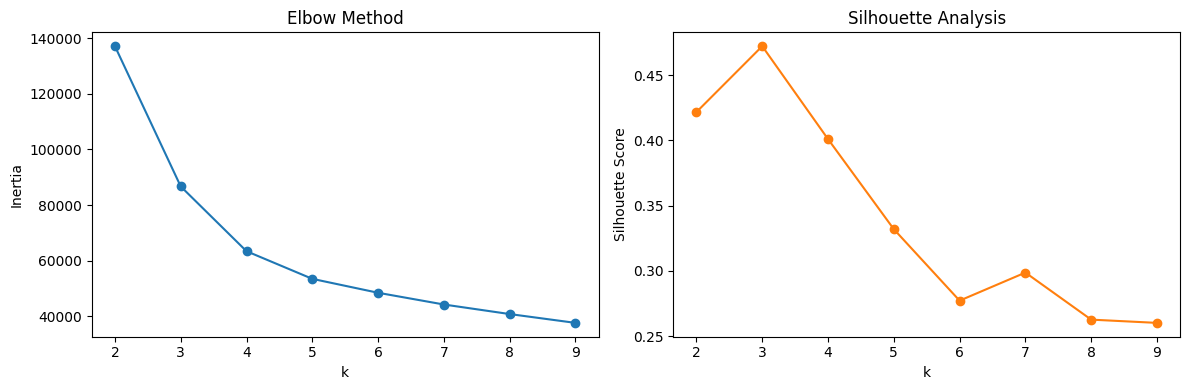

In [14]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_range = range(2, 10)

# Subsample for speed if the image is large
sample_idx = np.random.choice(X_scaled.shape[0], min(5000, X_scaled.shape[0]), replace=False)
X_sample = X_scaled[sample_idx]

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='tab:orange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Analysis')
plt.savefig("K means.png")
plt.tight_layout()
plt.show()

**Finding K value**
- Tested k = 2 to 9 using inertia (elbow method) and silhouette score on standardized band values (B2, B3, B4, B8, B11, B12)
- **Inertia** drops sharply from k=2→4, then flattens from k=5 onward — diminishing returns beyond ~3–4 clusters
- **Silhouette score** peaks at **k=3** (~0.47), indicating the most cohesive, well-separated clustering; declines steadily for k≥4
- Both metrics converge on **k=3** as the optimal cluster count

In [15]:
# ---------------------------------------------------------------
# 4. K-means clustering
# ---------------------------------------------------------------
k = 5   # number of land-cover clusters — tune this (see elbow method below)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_valid = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------------
# 5. Reshape labels back to the original (lat, lon) grid
# ---------------------------------------------------------------
labels_full = np.full(X.shape[0], np.nan)
labels_full[valid_mask] = labels_valid
label_grid = labels_full.reshape(lat_dim, lon_dim)[::-1]


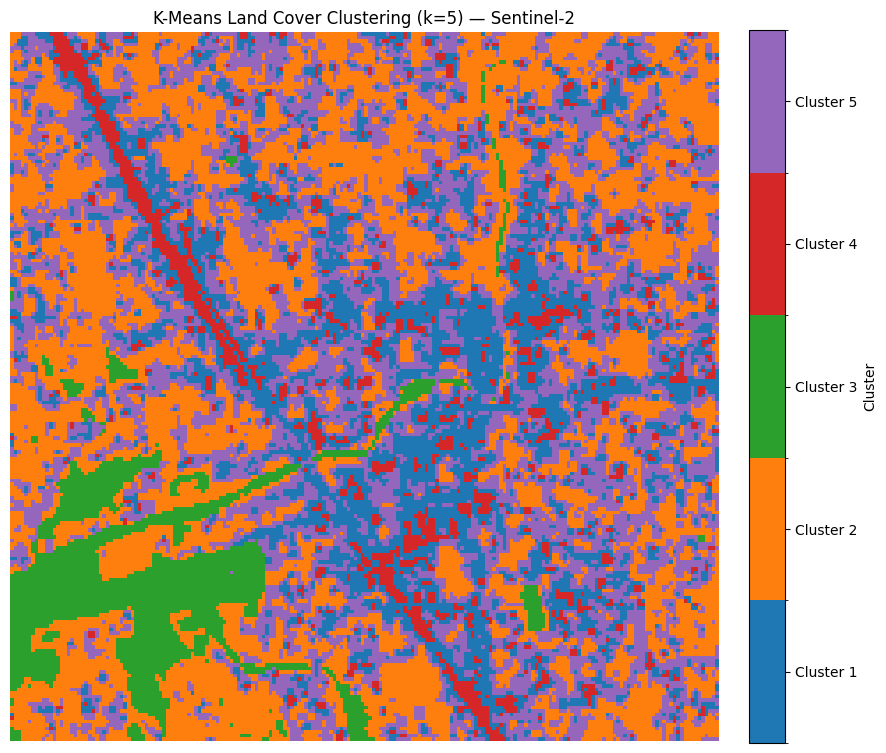

In [16]:
from matplotlib.colors import BoundaryNorm, ListedColormap

# Discrete colormap
cmap = ListedColormap(plt.cm.tab10.colors[:k])
bounds = np.arange(-0.5, k + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(label_grid, cmap=cmap, norm=norm)

ax.set_title(f'K-Means Land Cover Clustering (k={k}) — Sentinel-2')
ax.axis('off')

# Colorbar
cbar = plt.colorbar(im, ax=ax, ticks=range(k), fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels([f"Cluster {i+1}" for i in range(k)])
cbar.set_label("Cluster")

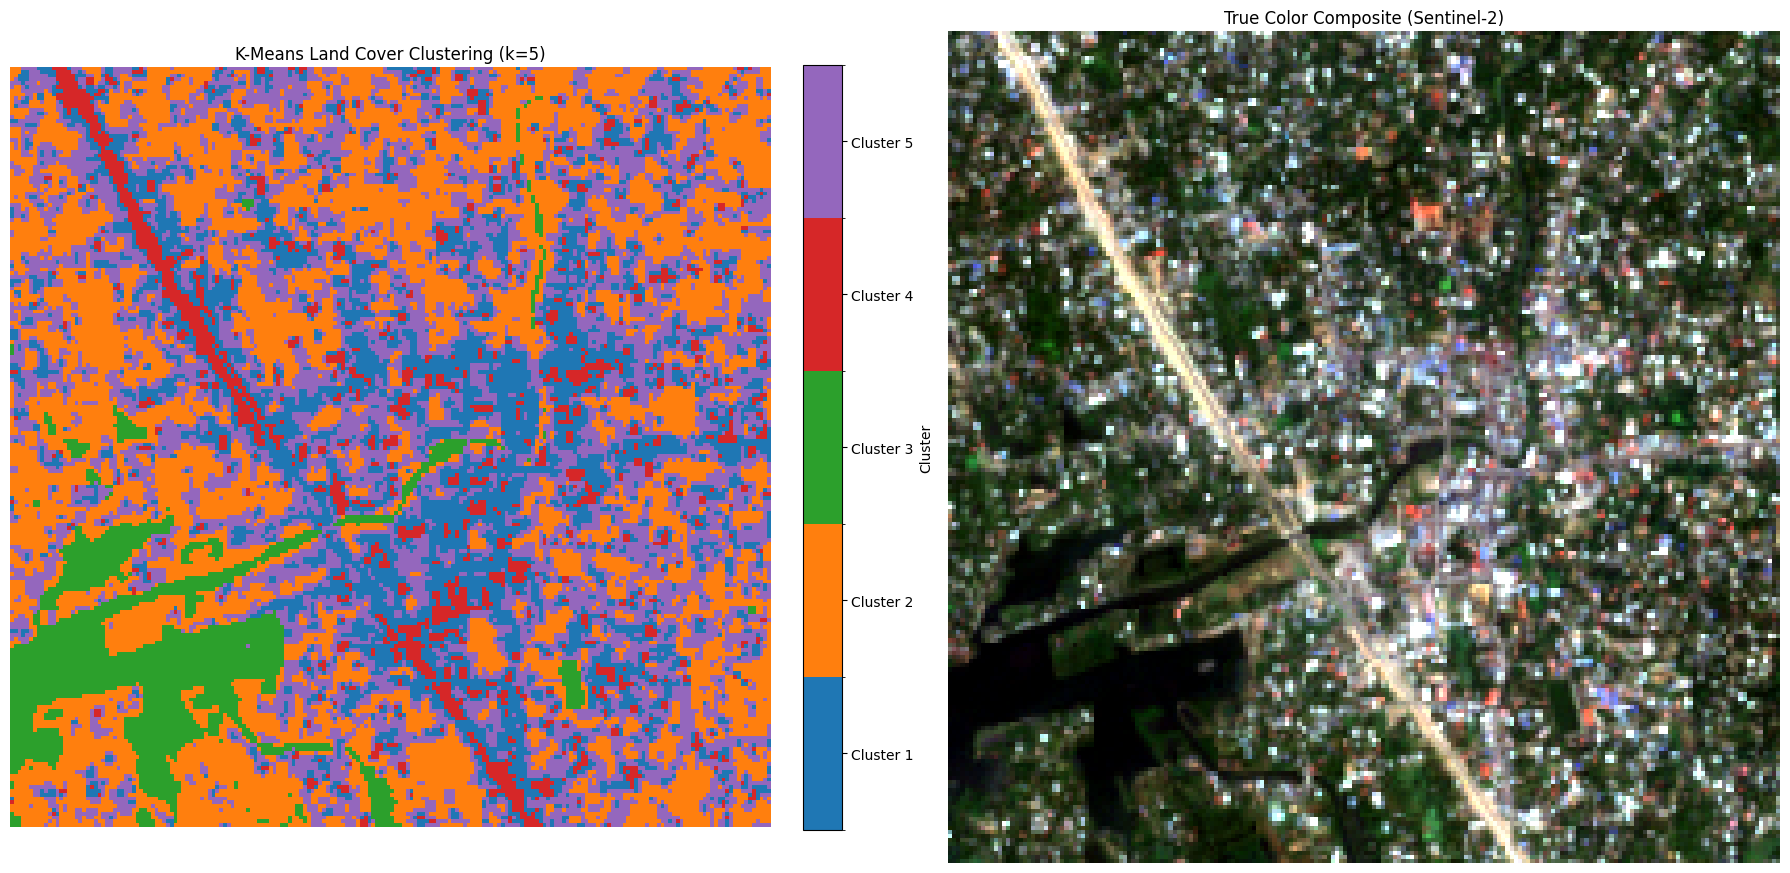

In [17]:
# -------------------------------
# Prepare True Color Composite
# -------------------------------
red   = normalize(ds_s2['B4'][0].values)[::-1]
green = normalize(ds_s2['B3'][0].values)[::-1]
blue  = normalize(ds_s2['B2'][0].values)[::-1]

true_color = np.dstack([red, green, blue])

# -------------------------------
# Cluster colormap
# -------------------------------
cmap = ListedColormap(plt.cm.tab10.colors[:k])
bounds = np.arange(-0.5, k + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(1, 2, figsize=(18, 9))

# K-Means clusters
im = ax[0].imshow(label_grid, cmap=cmap, norm=norm)
ax[0].set_title(f'K-Means Land Cover Clustering (k={k})')
ax[0].axis('off')

cbar = fig.colorbar(im, ax=ax[0], ticks=range(k),
                    fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels([f"Cluster {i+1}" for i in range(k)])
cbar.set_label("Cluster")

# True color image
ax[1].imshow(true_color)
ax[1].set_title('True Color Composite (Sentinel-2)')
ax[1].axis('off')

plt.tight_layout()
plt.show()